<a href="https://colab.research.google.com/github/nittloadeddiper/agri_price_pred/blob/main/winter_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/pro"  # 👈 folder name from Step 3

print(os.listdir(base_path))


['2018.csv', '2019.csv', '2020.csv', '2021.csv', '2022.csv', '2023.csv', '2024.csv', '2025.csv']


In [ ]:
import pandas as pd
import glob
import os

DATA_PATH = "/content/drive/MyDrive/pro"

files = sorted(glob.glob(os.path.join(DATA_PATH, "*.csv")))
print("Files found:", files)

dfs = []
for f in files:
    print("Reading:", f)
    df = pd.read_csv(f)
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)

print("Final shape:", full_df.shape)


Files found: ['/content/drive/MyDrive/pro/2018.csv', '/content/drive/MyDrive/pro/2019.csv', '/content/drive/MyDrive/pro/2020.csv', '/content/drive/MyDrive/pro/2021.csv', '/content/drive/MyDrive/pro/2022.csv', '/content/drive/MyDrive/pro/2023.csv', '/content/drive/MyDrive/pro/2024.csv', '/content/drive/MyDrive/pro/2025.csv']
Reading: /content/drive/MyDrive/pro/2018.csv
Reading: /content/drive/MyDrive/pro/2019.csv
Reading: /content/drive/MyDrive/pro/2020.csv
Reading: /content/drive/MyDrive/pro/2021.csv
Reading: /content/drive/MyDrive/pro/2022.csv
Reading: /content/drive/MyDrive/pro/2023.csv
Reading: /content/drive/MyDrive/pro/2024.csv
Reading: /content/drive/MyDrive/pro/2025.csv
Final shape: (36071887, 11)


In [ ]:
# Clean column names
full_df.columns = full_df.columns.str.strip()

# Convert date column (change name if needed)
full_df["Arrival_Date"] = pd.to_datetime(full_df["Arrival_Date"], errors="coerce")

# Drop broken rows
full_df = full_df.dropna(subset=["Arrival_Date"])

full_df.head()


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
0,Andhra Pradesh,Anantapur,Dharmavaram,Groundnut,Local,Medium,2018-01-01,4350.0,4450.0,4400.0,10
1,Andhra Pradesh,Anantapur,Dharmavaram,Paddy (Dhan)(Common),B P T,Medium,2018-01-01,1300.0,1300.0,1300.0,2
2,Andhra Pradesh,Anantapur,Hindupur,Tamarind Fruit,Karpuli A/c Fine,FAQ,2018-01-01,13000.0,18000.0,15500.0,261
3,Andhra Pradesh,Anantapur,Hindupur,Tamarind Fruit,With Seed 1Variety,FAQ,2018-01-01,3000.0,4500.0,3750.0,261
4,Andhra Pradesh,Anantapur,Hindupur,Tamarind Fruit,Flower A/c,FAQ,2018-01-01,8000.0,12000.0,10000.0,261


In [ ]:
full_df.tail()

,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Commodity_Code
36071882,Gujarat,Bharuch,Bharuch,Banana - Green,Other,FAQ,2025-11-06,400.0,700.0,500.0,90
36071883,Gujarat,Bharuch,Bharuch,Bhindi (Ladies Finger),Other,FAQ,2025-11-06,2000.0,2700.0,2200.0,85
36071884,Gujarat,Bharuch,Bharuch,Bottle gourd,Other,FAQ,2025-11-06,1000.0,2000.0,1500.0,82
36071885,Gujarat,Bharuch,Bharuch,Onion,Other,Non-FAQ,2025-11-06,1000.0,1700.0,1300.0,23
36071886,Uttar Pradesh,Khiri (Lakhimpur),Maigalganj,Wheat,Dara,FAQ,2025-11-06,2400.0,2465.0,2430.0,1


In [ ]:
full_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36071887 entries, 0 to 36071886
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   State           object        
 1   District        object        
 2   Market          object        
 3   Commodity       object        
 4   Variety         object        
 5   Grade           object        
 6   Arrival_Date    datetime64[ns]
 7   Min_Price       float64       
 8   Max_Price       float64       
 9   Modal_Price     float64       
 10  Commodity_Code  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 3.0+ GB


In [ ]:
full_df.nunique().sort_values(ascending=False)


,0
Modal_Price,46624
Max_Price,39279
Min_Price,30581
Market,3704
Arrival_Date,2867
Variety,1117
District,611
Commodity_Code,360
Commodity,358
State,32


In [ ]:
print("Start date:", full_df["Arrival_Date"].min())
print("End date:", full_df["Arrival_Date"].max())


Start date: 2018-01-01 00:00:00
End date: 2025-11-06 00:00:00


In [ ]:
full_df = full_df.sort_values("Arrival_Date")


In [ ]:
full_df[
    full_df["Commodity"].str.contains("Arhar|Tur", case=False, na=False)
]["Commodity"].value_counts()


,count
Commodity,
Arhar (Tur/Red Gram)(Whole),341036
Arhar Dal (Tur Dal),165979
Turmeric,48956
Turnip,32626
Pegeon Pea (Arhar Fali),10362
Turmeric (raw),6167
liquor turmeric,4


In [ ]:
# choose representative commodities
focus_commodities = [
    "Tomato",
    "Onion",
    "Arhar Dal (Tur Dal)"
]

# choose representative markets
focus_markets = [
    "Kolar",
    "Azadpur",
    "Bangalore"
]


In [ ]:
focus_df = full_df[
    (full_df["Commodity"].isin(focus_commodities)) &
    (full_df["Market"].isin(focus_markets))
].copy()


In [ ]:
focus_df.shape


(14497, 11)

In [ ]:
print("Commodities kept:")
print(focus_df["Commodity"].unique())

print("\nMarkets kept:")
print(focus_df["Market"].unique())


Commodities kept:
['Onion' 'Tomato' 'Arhar Dal (Tur Dal)']

Markets kept:
['Azadpur' 'Bangalore' 'Kolar']


In [ ]:
focus_df.groupby(["Commodity", "Market"]).size().sort_values(ascending=False)


Commodity            Market   
Onion                Bangalore    4934
Tomato               Kolar        3376
                     Azadpur      2110
Onion                Azadpur      1902
Arhar Dal (Tur Dal)  Bangalore    1767
Onion                Kolar         257
Arhar Dal (Tur Dal)  Kolar         151
dtype: int64

In [ ]:
# count observations per series
series_counts = focus_df.groupby(["Commodity", "Market"]).size()

# keep only series with at least 1000 observations
valid_series = series_counts[series_counts >= 1000].index

# filter focus_df
focus_df = focus_df.set_index(["Commodity", "Market"]).loc[valid_series].reset_index()

# check result
focus_df.groupby(["Commodity", "Market"]).size()


Commodity            Market   
Arhar Dal (Tur Dal)  Bangalore    1767
Onion                Azadpur      1902
                     Bangalore    4934
Tomato               Azadpur      2110
                     Kolar        3376
dtype: int64

In [ ]:
eda_df = focus_df[
    (focus_df["Commodity"] == "Onion") &
    (focus_df["Market"] == "Bangalore")
][["Arrival_Date", "Modal_Price"]].copy()

eda_df = eda_df.sort_values("Arrival_Date")
eda_df.shape


(4934, 2)

In [ ]:
eda_df["Arrival_Date"].diff().value_counts().head()


,count
Arrival_Date,
0 days,3139
1 days,1331
2 days,255
3 days,148
4 days,37


In [ ]:
ts_daily = (
    eda_df
    .groupby("Arrival_Date", as_index=True)
    .mean()          # handles 0-day duplicates
    .asfreq("D")     # creates daily index
)

ts_daily["Modal_Price"] = ts_daily["Modal_Price"].interpolate()


In [ ]:
ts_daily.head()


,Modal_Price
Arrival_Date,
2018-01-01,3250.0
2018-01-02,3250.0
2018-01-03,3425.0
2018-01-04,3450.0
2018-01-05,3400.0


In [ ]:
ts_daily.tail()


,Modal_Price
Arrival_Date,
2025-10-27,814.4
2025-10-28,807.2
2025-10-29,800.0
2025-10-30,800.0
2025-10-31,900.0


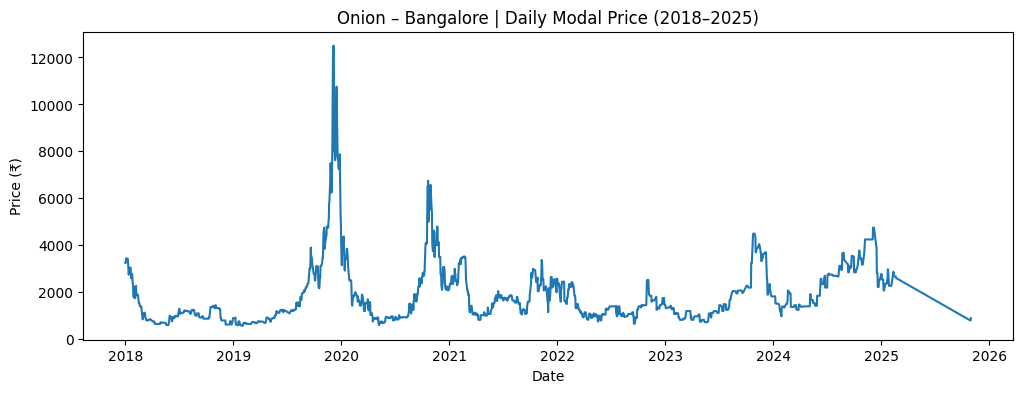

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ts_daily.index, ts_daily["Modal_Price"])
plt.title("Onion – Bangalore | Daily Modal Price (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.show()


In [ ]:
  eda_df.head()

,Arrival_Date,Modal_Price
3669,2018-01-01,3000.0
3670,2018-01-01,3500.0
3671,2018-01-02,3500.0
3672,2018-01-02,3000.0
3673,2018-01-03,3600.0


In [ ]:
eda_df.tail()

,Arrival_Date,Modal_Price
8596,2025-02-21,1800.0
8597,2025-02-21,2400.0
8600,2025-10-29,800.0
8601,2025-10-30,800.0
8602,2025-10-31,900.0


In [ ]:
tomato_kolar_df = full_df[
    (full_df["Commodity"] == "Tomato") &
    (full_df["Market"] == "Kolar")
][["Arrival_Date", "Modal_Price"]].copy()

tomato_kolar_df = tomato_kolar_df.sort_values("Arrival_Date")
tomato_kolar_df.shape


(3376, 2)

In [ ]:
tomato_kolar_df.head(), tomato_kolar_df.tail()


(      Arrival_Date  Modal_Price
 3341    2018-01-01        500.0
 3342    2018-01-01        516.0
 16127   2018-01-02        567.0
 16128   2018-01-02        520.0
 29328   2018-01-03        534.0,
          Arrival_Date  Modal_Price
 35878361   2025-10-14       1130.0
 35899423   2025-10-15       1330.0
 35919411   2025-10-16       1260.0
 35980878   2025-10-21       1460.0
 36010061   2025-10-27       1460.0)

In [ ]:
tomato_kolar_df["Arrival_Date"].diff().value_counts().head()


,count
Arrival_Date,
1 days,2641
0 days,664
2 days,46
3 days,10
5 days,4


In [ ]:
ts_daily = (
    tomato_kolar_df
    .groupby("Arrival_Date", as_index=True)
    .mean()
    .asfreq("D")
)

ts_daily["Modal_Price"] = ts_daily["Modal_Price"].interpolate()


In [ ]:
ts_daily.head()


,Modal_Price
Arrival_Date,
2018-01-01,508.0
2018-01-02,543.5
2018-01-03,517.0
2018-01-04,476.5
2018-01-05,433.5


In [ ]:
ts_daily.tail(13)

,Modal_Price
Arrival_Date,
2025-10-15,1330.0
2025-10-16,1260.0
2025-10-17,1300.0
2025-10-18,1340.0
2025-10-19,1380.0
2025-10-20,1420.0
2025-10-21,1460.0
2025-10-22,1460.0
2025-10-23,1460.0


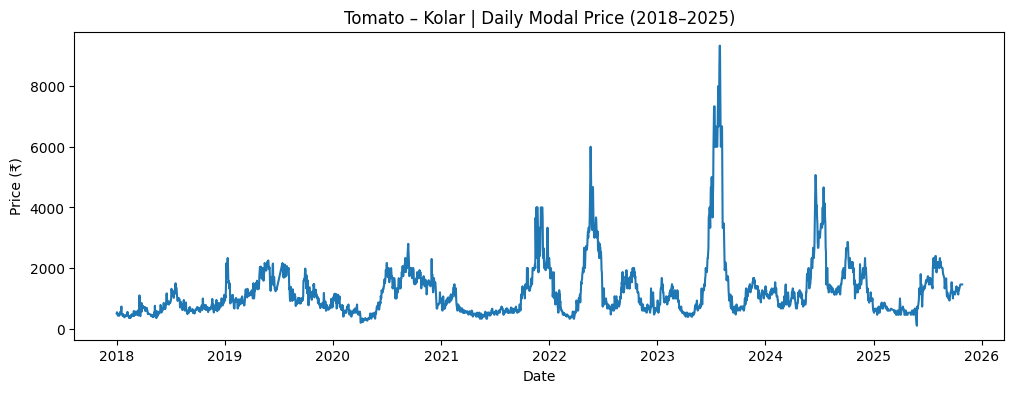

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ts_daily.index, ts_daily["Modal_Price"])
plt.title("Tomato – Kolar | Daily Modal Price (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.show()


In [ ]:
import numpy as np

log_price = np.log(ts_daily["Modal_Price"])


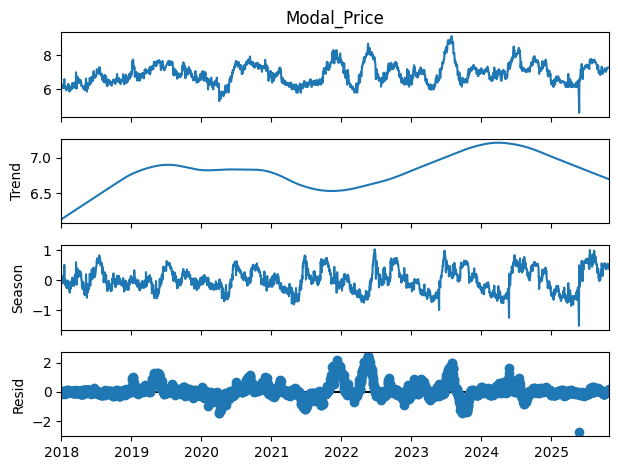

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(log_price, period=365, robust=True)
stl_result = stl.fit()

stl_result.plot()
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(log_price.dropna())

print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])


ADF Statistic: -5.603788714250119
ADF p-value: 1.2474869600057656e-06


In [ ]:
from statsmodels.tsa.stattools import kpss

kpss_stat, p_value, lags, crit = kpss(
    log_price.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_stat)
print("KPSS p-value:", p_value)


KPSS Statistic: 0.6885707271219628
KPSS p-value: 0.014584479352548838


In [ ]:
log_diff = log_price.diff().dropna()

from statsmodels.tsa.stattools import adfuller, kpss

print("ADF p-value (log-diff):", adfuller(log_diff)[1])
print("KPSS p-value (log-diff):", kpss(log_diff, regression="c", nlags="auto")[1])


ADF p-value (log-diff): 3.910844018034282e-16
KPSS p-value (log-diff): 0.1


/tmp/ipython-input-231779906.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS p-value (log-diff):", kpss(log_diff, regression="c", nlags="auto")[1])


<Figure size 1200x400 with 0 Axes>

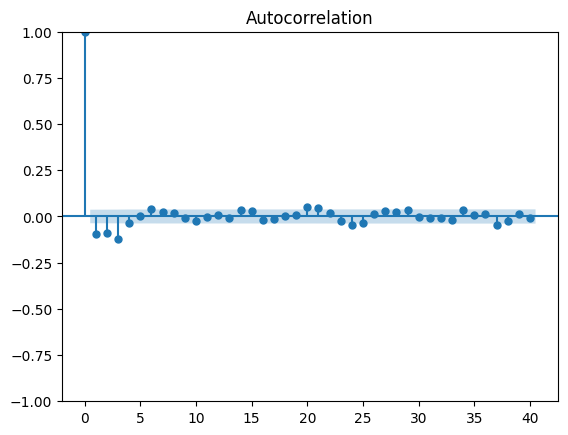

<Figure size 1200x400 with 0 Axes>

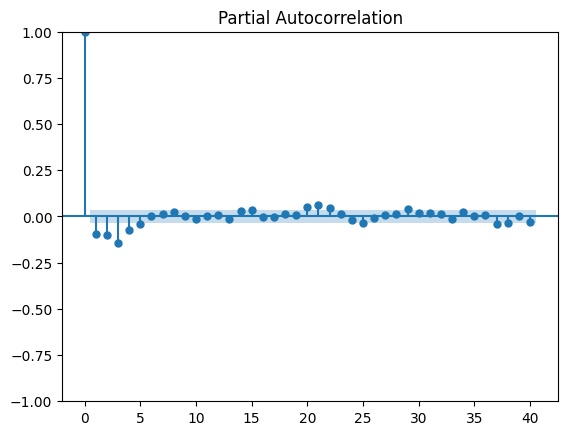

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plot_acf(log_diff, lags=40)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(log_diff, lags=40, method="ywm")
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

model = ARIMA(
    np.log(ts_daily["Modal_Price"]),
    order=(0, 1, 0)
)

model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            Modal_Price   No. Observations:                 2857
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1633.879
Date:                Wed, 14 Jan 2026   AIC                          -3265.758
Time:                        12:20:32   BIC                          -3259.801
Sample:                    01-01-2018   HQIC                         -3263.610
                         - 10-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0186      0.000    119.106      0.000       0.018       0.019
Ljung-Box (L1) (Q):                  25.00   Jarque-Bera (JB):             38309.77
Prob(Q):                              0.00   Pr

In [ ]:
import numpy as np

series = ts_daily["Modal_Price"].dropna()

train = series.iloc[:-30]
test = series.iloc[-30:]


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    np.log(train),
    order=(0, 1, 0)
)

model_fit = model.fit()


In [ ]:
forecast_log = model_fit.forecast(steps=30)


In [ ]:
forecast_price = np.exp(forecast_log)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast_price)
mse = mean_squared_error(test, forecast_price)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 122.16666666666667
RMSE: 156.0208319424044


In [ ]:
series = ts_daily["Modal_Price"].dropna()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def train_test_arima(train_series, test_series, order=(0,1,0)):
    model = ARIMA(np.log(train_series), order=order)
    model_fit = model.fit()

    forecast_log = model_fit.forecast(steps=len(test_series))
    forecast = np.exp(forecast_log)

    mae = mean_absolute_error(test_series, forecast)
    rmse = np.sqrt(mean_squared_error(test_series, forecast))

    return mae, rmse


In [ ]:
results = []

# Split 1: Train till 2023 → Test on 2024
train_2023 = series[:'2023-12-31']
test_2024  = series['2024-01-01':'2024-12-31']

mae_1, rmse_1 = train_test_arima(train_2023, test_2024)
results.append(("Train till 2023 → Test 2024", mae_1, rmse_1))


# Split 2: Train till 2024 → Test on 2025
train_2024 = series[:'2024-12-31']
test_2025  = series['2025-01-01':'2025-12-31']

mae_2, rmse_2 = train_test_arima(train_2024, test_2025)
results.append(("Train till 2024 → Test 2025", mae_2, rmse_2))


In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Split", "MAE", "RMSE"]
)

results_df


,Split,MAE,RMSE
0,Train till 2023 → Test 2024,573.618397,898.81540
1,Train till 2024 → Test 2025,505.333333,714.98649


In [ ]:
avg_mae = results_df["MAE"].mean()
avg_rmse = results_df["RMSE"].mean()

print("Average MAE:", avg_mae)
print("Average RMSE:", avg_rmse)


Average MAE: 539.4758652094717
Average RMSE: 806.9009451186614


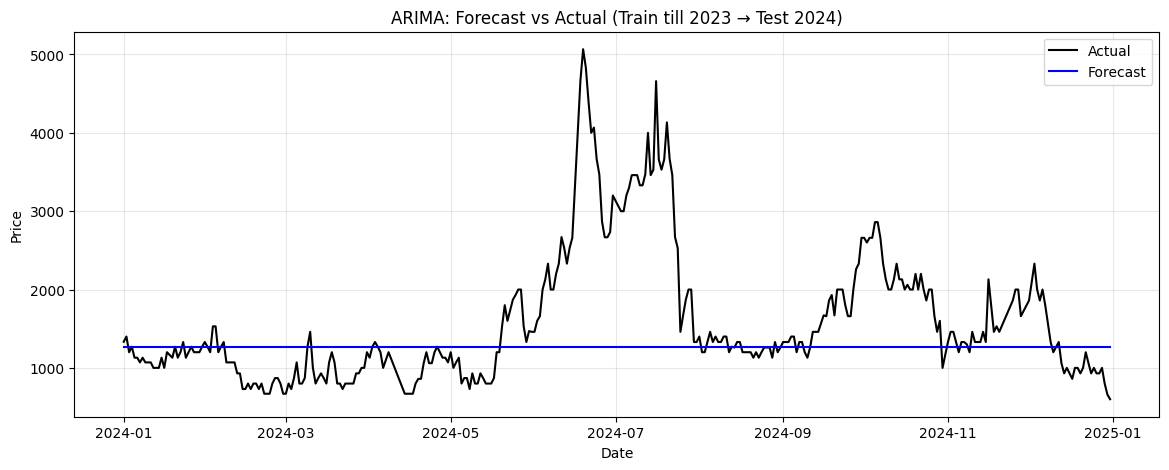

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Split
train = series[:'2023-12-31']
test  = series['2024-01-01':'2024-12-31']

# Train
model = ARIMA(np.log(train), order=(0,1,0))
model_fit = model.fit()

# Forecast
forecast_log = model_fit.forecast(steps=len(test))
forecast = np.exp(forecast_log)
forecast.index = test.index

# Plot
plt.figure(figsize=(14,5))
plt.plot(test.index, test.values, label="Actual", color="black")
plt.plot(forecast.index, forecast.values, label="Forecast", color="blue")
plt.title("ARIMA: Forecast vs Actual (Train till 2023 → Test 2024)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
train = series.iloc[:-30]
test  = series.iloc[-30:]


In [ ]:
train_log = np.log(train)


In [ ]:
model = ARIMA(
    train_log,
    order=(1, 1, 1)
)

model_fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MAE  : 128.29
RMSE : 159.92


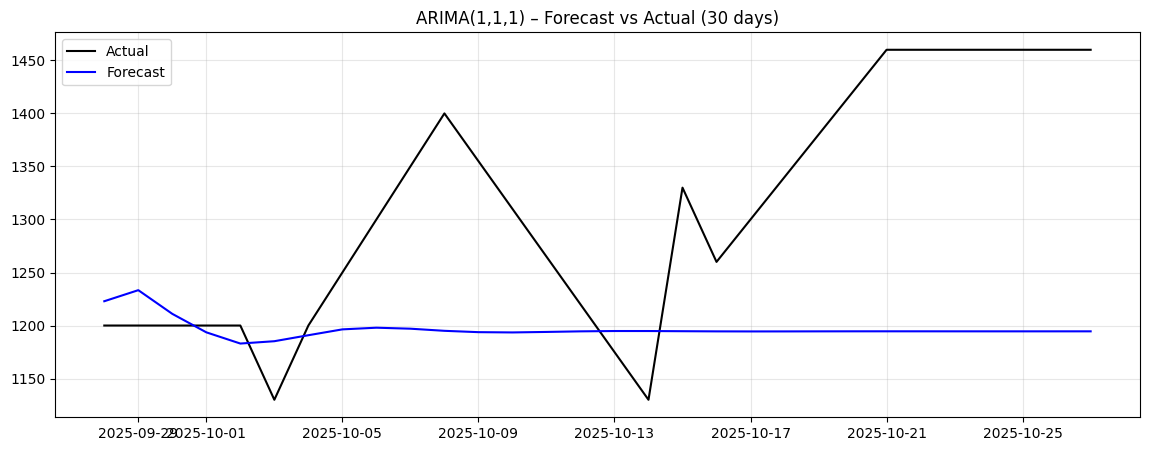

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1️⃣ Use your daily series
series = ts_daily["Modal_Price"].dropna()

# 2️⃣ FIXED split: last 30 days only
train = series.iloc[:-30]
test = series.iloc[-30:]     # EXACTLY 30 values

# 3️⃣ Log transform TRAIN only
train_log = np.log(train)

# 4️⃣ Train ARIMA
model = ARIMA(train_log, order=(3,1,4))
model_fit = model.fit()

# 5️⃣ Forecast EXACTLY 30 steps
forecast_log = model_fit.forecast(steps=30)
forecast = np.exp(forecast_log)

# 6️⃣ FORCE index match (CRITICAL)
forecast.index = test.index

# 7️⃣ Metrics (NO ERROR POSSIBLE)
mae = mean_absolute_error(test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(test.values, forecast.values))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# 8️⃣ Plot
plt.figure(figsize=(14,5))
plt.plot(test.index, test.values, label="Actual", color="black")
plt.plot(forecast.index, forecast.values, label="Forecast", color="blue")
plt.title("ARIMA(1,1,1) – Forecast vs Actual (30 days)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
LAT = 13.1367
LON = 78.1291


In [ ]:
import requests
import pandas as pd

start_date = "2018-01-01"
end_date   = "2025-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LAT}&longitude={LON}"
    f"&start_date={start_date}&end_date={end_date}"
    "&daily=temperature_2m_mean,relative_humidity_2m_mean,precipitation_sum"
    "&timezone=Asia/Kolkata"
)

response = requests.get(url)
data = response.json()

weather_df = pd.DataFrame({
    "Arrival_Date": pd.to_datetime(data["daily"]["time"]),
    "temp_mean": data["daily"]["temperature_2m_mean"],
    "humidity_mean": data["daily"]["relative_humidity_2m_mean"],
    "rainfall": data["daily"]["precipitation_sum"]
})

weather_df.head()


,Arrival_Date,temp_mean,humidity_mean,rainfall
0,2018-01-01,20.8,66,0.0
1,2018-01-02,21.8,66,0.0
2,2018-01-03,21.2,68,0.0
3,2018-01-04,20.5,69,0.0
4,2018-01-05,19.2,65,0.0


In [ ]:
price_df = ts_daily.reset_index()

merged_df = price_df.merge(
    weather_df,
    on="Arrival_Date",
    how="left"
)

merged_df = merged_df.set_index("Arrival_Date")
merged_df.head()


,Modal_Price,temp_mean,humidity_mean,rainfall
Arrival_Date,,,,
2018-01-01,508.0,20.8,66,0.0
2018-01-02,543.5,21.8,66,0.0
2018-01-03,517.0,21.2,68,0.0
2018-01-04,476.5,20.5,69,0.0
2018-01-05,433.5,19.2,65,0.0


In [ ]:
merged_df.head()


,Modal_Price,temp_mean,humidity_mean,rainfall
Arrival_Date,,,,
2018-01-01,508.0,20.8,66,0.0
2018-01-02,543.5,21.8,66,0.0
2018-01-03,517.0,21.2,68,0.0
2018-01-04,476.5,20.5,69,0.0
2018-01-05,433.5,19.2,65,0.0


In [ ]:
merged_df.tail()


,Modal_Price,temp_mean,humidity_mean,rainfall
Arrival_Date,,,,
2025-10-23,1460.0,22.4,88,12.6
2025-10-24,1460.0,22.6,77,0.7
2025-10-25,1460.0,23.1,79,0.8
2025-10-26,1460.0,23.4,79,0.0
2025-10-27,1460.0,21.8,86,3.5


In [ ]:
merged_df.isna().sum()


,0
Modal_Price,0
temp_mean,0
humidity_mean,0
rainfall,0


In [ ]:
final_df = merged_df.copy()
final_df.head()


,Modal_Price,temp_mean,humidity_mean,rainfall
Arrival_Date,,,,
2018-01-01,508.0,20.8,66,0.0
2018-01-02,543.5,21.8,66,0.0
2018-01-03,517.0,21.2,68,0.0
2018-01-04,476.5,20.5,69,0.0
2018-01-05,433.5,19.2,65,0.0


In [ ]:
!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport


In [ ]:
profile = ProfileReport(
    final_df.reset_index(),   # include date as column
    title="Tomato–Kolar Price & Weather Profiling",
    explorative=True
)


In [ ]:
profile.to_file("tomato_kolar_profiling.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 76.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
y = final_df["Modal_Price"]
X = final_df[["rainfall", "temp_mean", "humidity_mean"]]


In [ ]:
y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]


In [ ]:
import numpy as np

y_train_log = np.log(y_train)


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train_log,
    exog=X_train,
    order=(1, 1, 1),          # ARIMA part
    seasonal_order=(0, 0, 0, 0),  # no seasonality for now
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast_log = model_fit.forecast(
    steps=len(y_test),
    exog=X_test
)

forecast = np.exp(forecast_log)
forecast.index = y_test.index


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test.values, forecast.values)
rmse = np.sqrt(mean_squared_error(y_test.values, forecast.values))

print(f"SARIMAX MAE : {mae:.2f}")
print(f"SARIMAX RMSE: {rmse:.2f}")


SARIMAX MAE : 122.14
SARIMAX RMSE: 153.67


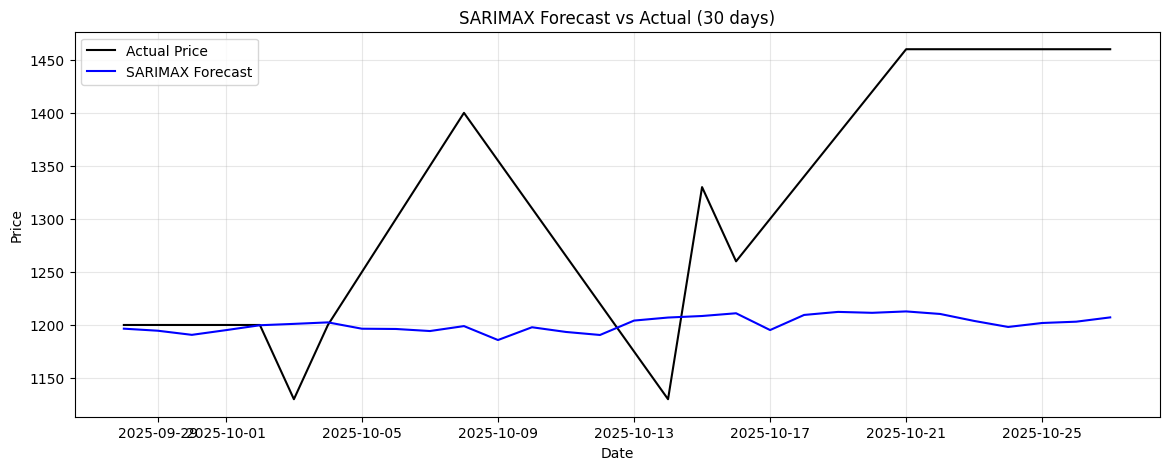

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test.values, label="Actual Price", color="black")
plt.plot(forecast.index, forecast.values, label="SARIMAX Forecast", color="blue")

plt.title("SARIMAX Forecast vs Actual (30 days)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_sarimax(final_df, train_end, test_start, test_end):

    # Split target and exogenous variables
    y = final_df["Modal_Price"]
    X = final_df[["rainfall", "temp_mean", "humidity_mean"]]

    y_train = y[:train_end]
    y_test  = y[test_start:test_end]

    X_train = X[:train_end]
    X_test  = X[test_start:test_end]

    # Log transform target only
    y_train_log = np.log(y_train)

    # Train SARIMAX
    model = SARIMAX(
        y_train_log,
        exog=X_train,
        order=(1,1,1),
        seasonal_order=(1,0,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    # Forecast
    forecast_log = model_fit.forecast(
        steps=len(y_test),
        exog=X_test
    )

    forecast = np.exp(forecast_log)
    forecast.index = y_test.index

    # Metrics
    mae = mean_absolute_error(y_test.values, forecast.values)
    rmse = np.sqrt(mean_squared_error(y_test.values, forecast.values))

    # Plot
    plt.figure(figsize=(14,5))
    plt.plot(y_test.index, y_test.values, label="Actual", color="black")
    plt.plot(forecast.index, forecast.values, label="SARIMAX Forecast", color="blue")
    plt.title(f"SARIMAX Forecast vs Actual ({train_end} → {test_end})")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return mae, rmse


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


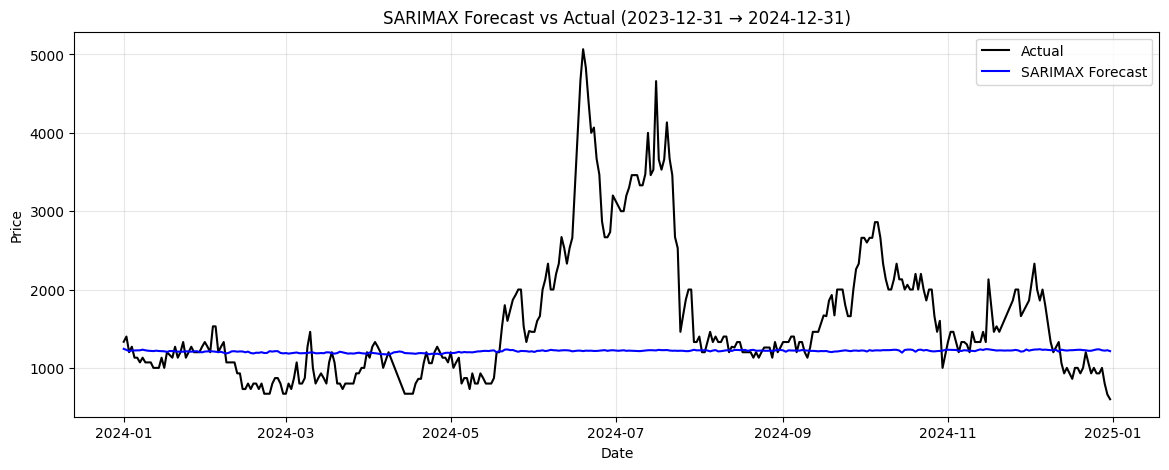

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


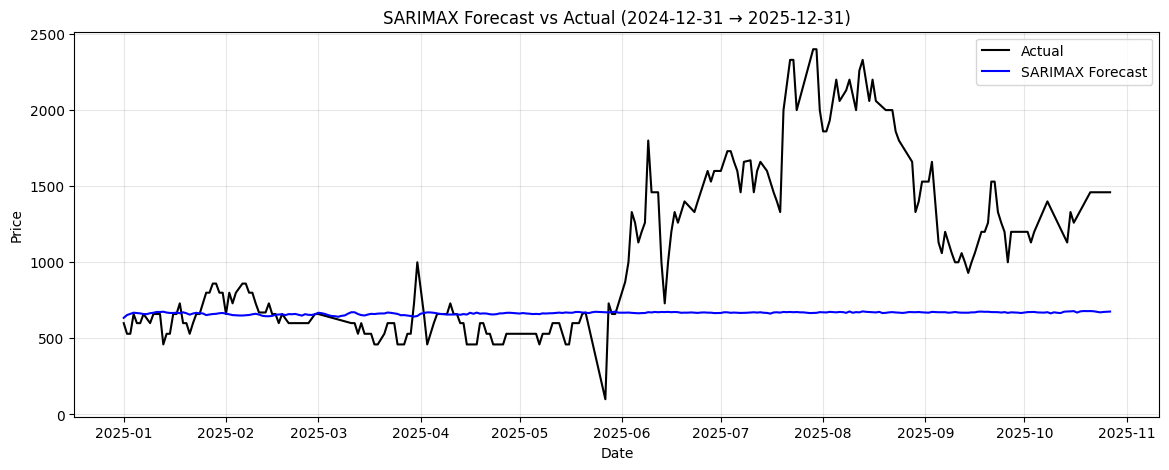

In [ ]:
results = []

# Train till 2023 → Test on 2024
mae_1, rmse_1 = evaluate_sarimax(
    final_df,
    train_end="2023-12-31",
    test_start="2024-01-01",
    test_end="2024-12-31"
)
results.append(("Train till 2023 → Test 2024", mae_1, rmse_1))


# Train till 2024 → Test on 2025
mae_2, rmse_2 = evaluate_sarimax(
    final_df,
    train_end="2024-12-31",
    test_start="2025-01-01",
    test_end="2025-12-31"
)
results.append(("Train till 2024 → Test 2025", mae_2, rmse_2))


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

series = ts_daily["Modal_Price"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_series = scaler.fit_transform(series)


In [ ]:
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_series, window_size=30)


In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))


In [ ]:
X.shape


(2827, 30, 1)

In [ ]:
X_train = X[:-30]
X_test  = X[-30:]

y_train = y[:-30]
y_test  = y[-30:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30,1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,          # enough to learn patterns
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0062 - val_loss: 7.1103e-04
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 4.8168e-04
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 4.5246e-04
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 4.5968e-04
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 3.8423e-04
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019 - val_loss: 5.8068e-04
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 3.6588e-04
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 3.3994e-04
Epoch 9/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 3.2498e-04
Epoch 10/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 5.3316e-04
Epoch 11/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 3.9844e-04
Epoch 12/25
79/79 ━━━━━━━━

In [ ]:
  pred_scaled = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


In [ ]:
pred_price = scaler.inverse_transform(pred_scaled)
y_test_price = scaler.inverse_transform(y_test.reshape(-1,1))


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_price, pred_price)
rmse = np.sqrt(mean_squared_error(y_test_price, pred_price))

print("LSTM MAE :", mae)
print("LSTM RMSE:", rmse)


LSTM MAE : 46.93769938151042
LSTM RMSE: 59.88155350441396


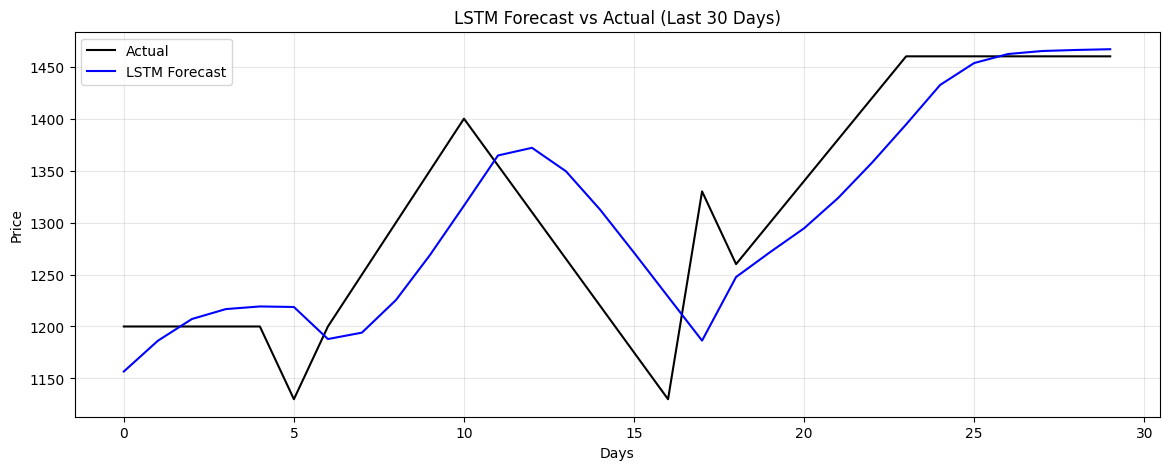

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_price, label="Actual", color="black")
plt.plot(pred_price, label="LSTM Forecast", color="blue")
plt.title("LSTM Forecast vs Actual (Last 30 Days)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import pandas as pd

features = ["Modal_Price", "rainfall", "temp_mean", "humidity_mean"]
data = final_df[features].copy()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data.shape


(2857, 4)

In [ ]:
def create_multivariate_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])   # all features
        y.append(data[i, 0])                 # target = price only
    return np.array(X), np.array(y)

WINDOW = 30
X, y = create_multivariate_sequences(scaled_data, WINDOW)

X.shape, y.shape


((2827, 30, 4), (2827,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, X.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0099 - val_loss: 5.0208e-04
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0026 - val_loss: 4.8217e-04
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 4.6017e-04
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 3.9375e-04
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 3.9695e-04
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 3.9753e-04
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 3.2475e-04
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.3297e-04
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 3.2455e-04
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.1969e-04
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 3.7937e-04
Epoch 12/30
79/79 ━━━━━━━━━━

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0092 - val_loss: 7.1552e-04
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 8.4889e-04
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 3.9759e-04
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 3.5768e-04
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 3.5905e-04
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 4.1093e-04
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.3652e-04
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 3.3809e-04
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 3.2515e-04
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.0568e-04
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 4.2177e-04
Epoch 12/30
79/79 ━━━━━━━━━━━

In [ ]:
features = ["Modal_Price", "rainfall", "temp_mean", "humidity_mean"]
data = final_df[features].dropna()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)


In [ ]:
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])   # ALL FEATURES
        y.append(data[i, 0])               # Modal_Price ONLY
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_data, LOOKBACK)


In [ ]:
print(X.shape)
print(y.shape)


(2827, 30, 4)
(2827,)


In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0097 - val_loss: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0033 - val_loss: 6.2135e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 5.6883e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 4.1615e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 4.9780e-04
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 3.3228e-04
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 9.7623e-04
Epoch 9/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 6.1861e-04
Epoch 10/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 3.3416e-04
Epoch 11/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 3.1288e-04
Epoch 12/30
64/64 ━━━━━━━━━━━━━━━

In [ ]:
y_pred_scaled = model.predict(X_test)

# Inverse scaling (Modal_Price only)
dummy = np.zeros((len(y_pred_scaled), scaled_data.shape[1]))
dummy[:, 0] = y_pred_scaled[:, 0]

y_pred = scaler.inverse_transform(dummy)[:, 0]

y_test_real = data["Modal_Price"].values[-len(y_pred):]


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 170.6176267998475
RMSE: 271.00288327417223


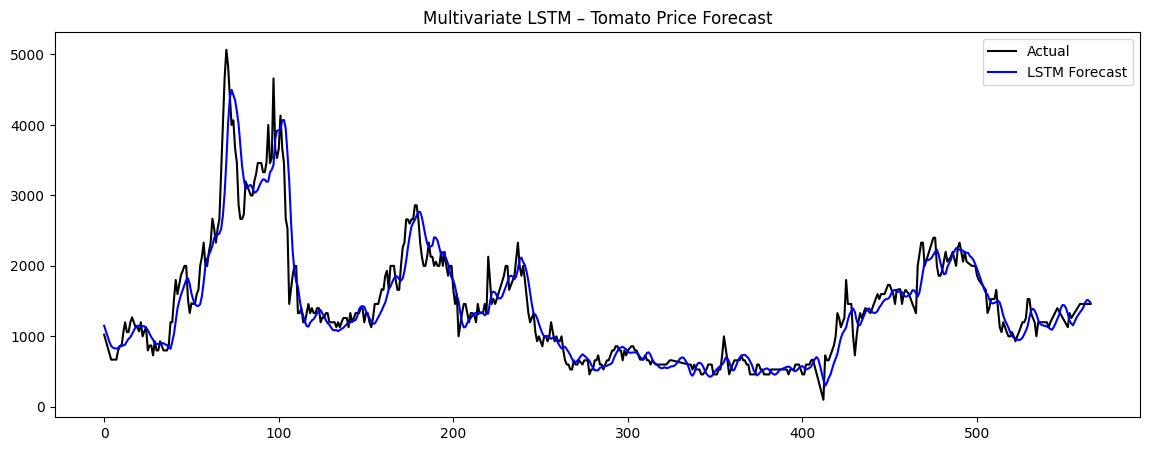

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_real, label="Actual", color="black")
plt.plot(y_pred, label="LSTM Forecast", color="blue")
plt.title("Multivariate LSTM – Tomato Price Forecast")
plt.legend()
plt.show()


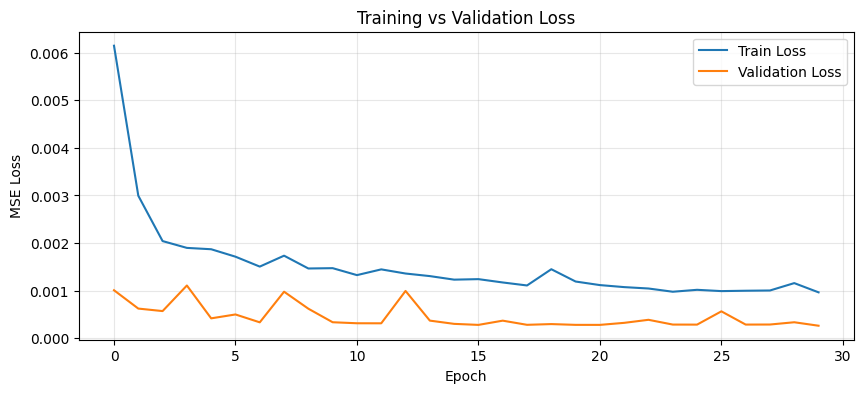

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
def build_lstm_model(hp):
    model = Sequential()

    units_1 = hp.Choice("units_1", values=[32, 64, 96])
    units_2 = hp.Choice("units_2", values=[16, 32])
    dropout = hp.Float("dropout", min_value=0.1, max_value=0.4, step=0.1)
    lr = hp.Choice("lr", values=[1e-2, 1e-3])

    model.add(
        LSTM(
            units_1,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )
    model.add(Dropout(dropout))

    model.add(LSTM(units_2))
    model.add(Dropout(dropout))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )

    return model


In [ ]:
tuner = kt.RandomSearch(
    build_lstm_model,
    objective="val_loss",
    max_trials=10,            # enough
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="mandi_price_lstm"
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [ ]:
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Trial 10 Complete [00h 00m 09s]
val_loss: 0.0002562996814958751

Best val_loss So Far: 0.00019867430091835558
Total elapsed time: 00h 02m 30s


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0022 - val_loss: 3.9971e-04
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024 - val_loss: 2.5428e-04
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 1.9926e-04
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 1.9494e-04
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 1.9887e-04
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 2.0309e-04
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 1.9612e-04
Epoch 8/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - val_loss: 5.8999e-04
Epoch 9/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 1.8847e-04
Epoch 10/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020 - val_loss: 2.9689e-04
Epoch 11/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.6599e-04
Epoch 12/40
64/64 ━━━━━━━

In [ ]:
y_pred_scaled = best_model.predict(X_test)

dummy = np.zeros((len(y_pred_scaled), scaled_data.shape[1]))
dummy[:,0] = y_pred_scaled.flatten()

y_pred = scaler.inverse_transform(dummy)[:,0]
y_test_real = data["Modal_Price"].values[-len(y_pred):]

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

print("FINAL LSTM MAE :", mae)
print("FINAL LSTM RMSE:", rmse)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
FINAL LSTM MAE : 136.2143464568559
FINAL LSTM RMSE: 203.36669915353164


In [ ]:
import pandas as pd
import numpy as np

residuals = y_test_real - y_pred


In [ ]:
  window = 7   # 7-day volatility (can also try 14)

  actual_volatility = (
      pd.Series(residuals)
      .rolling(window)
      .std()
  )


In [ ]:
predicted_volatility = (
    pd.Series(y_pred)
    .rolling(window)
    .std()
)


In [ ]:
vol_df = pd.DataFrame({
    "Actual_Volatility": actual_volatility,
    "Predicted_Volatility": predicted_volatility
}).dropna()


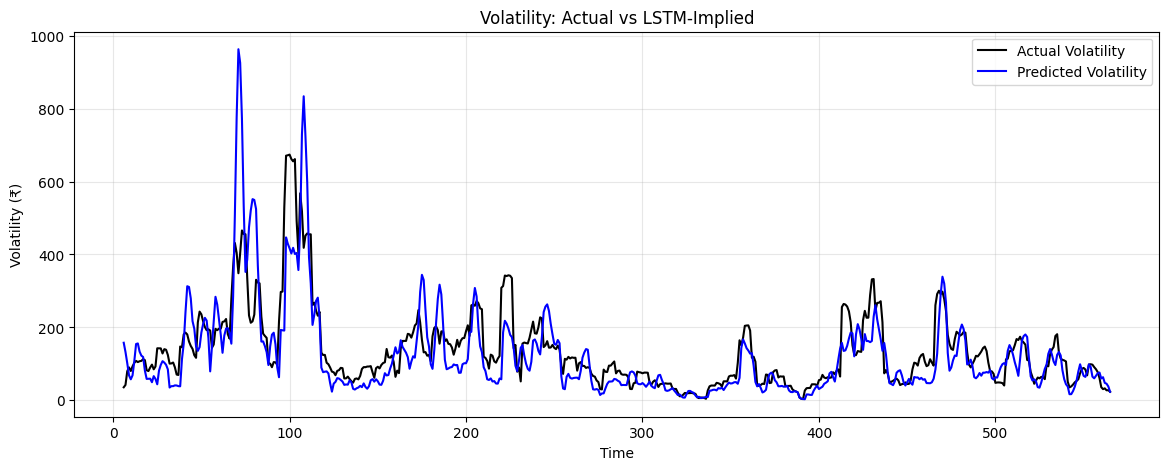

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(vol_df["Actual_Volatility"], label="Actual Volatility", color="black")
plt.plot(vol_df["Predicted_Volatility"], label="Predicted Volatility", color="blue")

plt.title("Volatility: Actual vs LSTM-Implied")
plt.xlabel("Time")
plt.ylabel("Volatility (₹)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
vol_corr = vol_df["Actual_Volatility"].corr(vol_df["Predicted_Volatility"])
print("Volatility Correlation:", round(vol_corr, 3))


Volatility Correlation: 0.776


In [ ]:
def risk_label(vol):
    if vol < low_threshold:
        return "LOW RISK"
    elif vol < high_threshold:
        return "MEDIUM RISK"
    else:
        return "HIGH RISK"
